In [222]:
# 导入 PyTorch 主库,提供张量(tensor)、自动求导、GPU 加速等核心能力
import torch
# 导入 torch.nn 子模块,里面是搭神经网络用的层(Linear、Conv2d 等)和激活函数(Tanh、ReLU 等),按惯例起别名 nn
import torch.nn as nn

In [223]:
# 观测空间维度:环境返回给 agent 的状态向量长度。
# 例如 CartPole-v1 的 observation 是 [x, x_dot, theta, theta_dot],共 4 维,所以 obs_dim=4。
# 注意:obs_dim 必须是 int,不能是 list —— 它是网络第一层 Linear 的输入宽度。
obs_dim = 4

# 动作空间维度:策略网络最后一层要输出多少个数。
# 离散动作(如 CartPole 只能左/右推)时,act_dim = 动作数量 = 2,输出解释为每个动作的 logits。
# 连续动作时,act_dim = 动作向量长度,输出解释为每维的均值(或分布参数)。
act_dim = 2

In [224]:
# 定义策略网络 π(a|s):输入观测,输出动作(或动作分布参数)。
# nn.Sequential 把一串层按顺序串起来,前一层输出直接当下一层输入,forward 时按顺序跑一遍。
pi_net = nn.Sequential(
    # 第 1 层:全连接层,把 obs_dim 维观测线性映射到 64 维隐藏特征
    nn.Linear(obs_dim, 64),
    # 激活函数 Tanh:把每个元素压到 (-1, 1),给网络加入非线性;RL 里 Tanh 比 ReLU 更常见(梯度更平滑、输出有界)
    nn.Tanh(),
    # 第 2 层:64 → 64 的隐藏层,加深网络表达能力
    nn.Linear(64, 64),
    # 再次 Tanh 激活
    nn.Tanh(),
    # 输出层:64 → act_dim。不加激活,原始输出叫 logits(离散动作时喂给 softmax / Categorical 采样)
    nn.Linear(64, act_dim),
)

# 打印网络结构,确认每层输入输出维度对得上
print(pi_net)

Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=2, bias=True)
)


In [225]:
# 造一个假的观测,用来测试网络能不能正常前向传播。
# 真实场景下 obs 来自 env.reset() 或 env.step(action) 的返回值,通常是 numpy.ndarray。
# 这里用 [0.1, 0.0, -0.05, 0.2] 模拟 CartPole 的一个 4 维观测,长度必须等于 obs_dim。
obs = [0.1, 0.0, -0.05, 0.2]

# 把 Python list / numpy 数组转成 PyTorch 张量。
# dtype=torch.float32:神经网络权重默认是 float32,输入也得是 float32 才能相乘,否则会报 dtype mismatch。
# torch.as_tensor 比 torch.tensor 更省一次拷贝(能共享内存就共享)。
obs_tensor = torch.as_tensor(obs, dtype=torch.float32)

# 前向传播:把观测喂进策略网络,得到动作 logits(shape = [act_dim])。
# 网络内部依次执行:Linear → Tanh → Linear → Tanh → Linear,不做 softmax。
# 训练时通常再用 torch.distributions.Categorical(logits=actions) 采样离散动作。
actions_logits = pi_net(obs_tensor)

# 打印看看:logits 张量本身,以及它的形状——形状应为 torch.Size([2]),对应两个离散动作的分数
print("logits:", actions_logits)
print("shape :", actions_logits.shape)

logits: tensor([-0.2738, -0.1370], grad_fn=<ViewBackward0>)
shape : torch.Size([2])


In [226]:
# ============================================================
# Step A:从策略网络采样动作
# ============================================================
# 上一 cell 已经拿到 logits = pi_net(obs_tensor),shape=[act_dim]=[2]。
# logits 是"没归一化的分数",不是概率;要变成概率需要 softmax,再从里面按概率抽一个动作。
# PyTorch 把这一整套封装成 torch.distributions.Categorical,直接喂 logits 就行(内部帮你做 softmax)。

# 导入分类分布类。RL 里最常用的两个分布:
#   - Categorical:离散动作(CartPole、Atari 等)
#   - Normal:连续动作(机器人控制等)
from torch.distributions import Categorical

# 用 logits 构造一个离散分布对象 dist。
# 等价于概率 probs = softmax(logits),但直接传 logits 数值更稳(避免 exp 溢出)。
dist = Categorical(logits=actions_logits)

# 打印当前策略下每个动作的概率,方便直观理解 logits → 概率的映射
print("logits :", actions_logits.detach().numpy())      # 原始分数
print("probs  :", dist.probs.detach().numpy())  # softmax 后的概率,和为 1


logits : [-0.27381548 -0.13695504]
probs  : [0.46583822 0.5341618 ]


In [227]:
# 从分布里采样一个动作。返回的是标量 tensor(shape=[]),值 ∈ {0, 1, ..., act_dim-1}。
# .sample() 内部不带梯度(采样操作不可导),这是 REINFORCE 用 log-prob trick 而不是直接 backprop 的根本原因。
action = dist.sample()
print("action :", action.item())  # .item() 把 0 维 tensor 转成 Python int,喂给 env.step() 时会用到

# 拿到这个动作在当前策略下的 log 概率:log π(a|s)。
# 这是 policy gradient 的核心量 —— 训练时 loss = -(log_prob * return).mean(),
# .backward() 时梯度会顺着 log_prob 传回 pi_net 的参数。
# 注意:log_prob 保留了对 logits 的梯度(grad_fn 会显示),这就是"可导"的通道。
log_prob = dist.log_prob(action)
print("log_prob:", log_prob)  # 应带 grad_fn=<SqueezeBackward1> 之类

# 顺便看看分布的熵 H(π) = -Σ p·log p。熵越大代表策略越"不确定"、探索性越强。
# 很多算法(PPO/A2C)会在 loss 里加 -β·entropy 项鼓励探索,防止过早收敛到确定策略。
entropy = dist.entropy()
print("entropy:", entropy.item())

# 小实验:采样 10 次,看看动作分布是否与 probs 匹配
samples = torch.stack([dist.sample() for _ in range(10)])
print("10 samples:", samples.tolist())

action : 0
log_prob: tensor(-0.7639, grad_fn=<SqueezeBackward1>)
entropy: 0.6908113956451416
10 samples: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]


In [228]:
log_prob.backward()
print(pi_net[0].weight.grad.abs().sum())

tensor(0.4377)


In [229]:

import numpy as np

arr = np.array([1, 2, 3, 4, 5])

print(arr)
print(type(arr))
print(np.__version__)

arr = np.array((1,2,5,6,89,75))
print(arr)

arr = np.array(42)
print(arr)

arr = np.array([[1, 2, 3], [4, 5, 6]])
print(arr)


[1 2 3 4 5]
<class 'numpy.ndarray'>
2.5.0
[ 1  2  5  6 89 75]
42
[[1 2 3]
 [4 5 6]]


In [230]:
arr = np.array([[[1, 2, 3], [4, 5, 6]], [[1, 2, 3], [4, 5, 6]]])
print(arr)

[[[1 2 3]
  [4 5 6]]

 [[1 2 3]
  [4 5 6]]]


In [231]:

a = np.array(42)
b = np.array([1, 2, 3, 4, 5])
c = np.array([[1, 2, 3], [4, 5, 6]])
d = np.array([[[1, 2, 3], [4, 5, 6]], [[1, 2, 3], [4, 5, 6]]])

print(a.ndim)
print(b.ndim)
print(c.ndim)
print(d.ndim) 

0
1
2
3


In [232]:

arr = np.array([1, 2, 3, 4], ndmin=5)

print(arr)
print('number of dimensions :', arr.ndim) 

[[[[[1 2 3 4]]]]]
number of dimensions : 5


In [233]:
print(arr[0]) 

arr = np.array([1, 2, 3, 4])

print(arr[2] + arr[3])

[[[[1 2 3 4]]]]
7


In [234]:
arr = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])

print(arr[0, 1, 2])

6


In [235]:

arr = np.array([[1,2,3,4,5], [6,7,8,9,10]])

print('Last element from 2nd dim: ', arr[1, -1]) 

Last element from 2nd dim:  10


In [236]:

arr = np.array([1, 2, 3, 4, 5, 6, 7])

print(arr[4:]) 

[5 6 7]


In [237]:
print(arr[-3:-1]) 
print(arr[1:5:2]) 
print(arr[:4]) 
print(arr[::2]) 

[5 6]
[2 4]
[1 2 3 4]
[1 3 5 7]


In [238]:
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])

print(arr[1, 1:4])

[7 8 9]


In [239]:
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])

print(arr[0:2, 2]) 

[3 8]


In [240]:
arr = np.array([[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]])

print(arr[0:2, 1:4]) 

[[2 3 4]
 [7 8 9]]


In [241]:
arr = np.array([1, 2, 3, 4])

print(arr.dtype) 

int64


In [242]:

arr = np.array([1, 2, 3, 4], dtype='S')

print(arr)
print(arr.dtype) 

[b'1' b'2' b'3' b'4']
|S1


In [243]:

arr = np.array([1, 2, 3, 4], dtype='i4')

print(arr)
print(arr.dtype) 

[1 2 3 4]
int32


In [244]:
arr = np.array([1.1, 2.9, 3.1])

newarr = arr.astype('i')

print(newarr)
print(newarr.dtype) 

[1 2 3]
int32


In [245]:
newarr = arr.astype(int)

print(newarr)
print(newarr.dtype) 

[1 2 3]
int64


In [246]:
arr = np.array([1, 0, 3])

newarr = arr.astype(bool)

print(newarr)
print(newarr.dtype) 

[ True False  True]
bool


In [247]:
arr = np.array([1, 2, 3, 4, 5])
x = arr.copy()
arr[0] = 42

print(arr)
print(x) 

[42  2  3  4  5]
[1 2 3 4 5]


In [248]:
arr = np.array([1, 2, 3, 4, 5])
x = arr.view()
arr[0] = 42

print(arr)
print(x) 

[42  2  3  4  5]
[42  2  3  4  5]


In [249]:
arr = np.array([1, 2, 3, 4, 5])
x = arr.view()
x[0] = 31

print(arr)
print(x) 

[31  2  3  4  5]
[31  2  3  4  5]


In [250]:

arr = np.array([1, 2, 3, 4, 5])

x = arr.copy()
y = arr.view()

print(x.base)
print(y.base)

None
[1 2 3 4 5]


In [251]:
arr = np.array([1, 2, 3, 4], ndmin=5)

print(arr)
print('shape of array :', arr.shape) 

[[[[[1 2 3 4]]]]]
shape of array : (1, 1, 1, 1, 4)


In [252]:
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

newarr = arr.reshape(4, 3)

print(newarr) 

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


In [253]:

arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

newarr = arr.reshape(2, 3, 2)

print(newarr) 

[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]]


In [254]:

arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])

print(arr.reshape(2, 4).base) 

[1 2 3 4 5 6 7 8]


In [255]:
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])

newarr = arr.reshape(2, 2, -1)


print(newarr)

[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]


In [256]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

newarr = arr.reshape(-1)

print(newarr) 

[1 2 3 4 5 6]


In [257]:
arr = np.array([1, 2, 3])

for x in arr:
  print(x) 

1
2
3


In [258]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

for x in arr:
  print(x) 

[1 2 3]
[4 5 6]


In [259]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

for x in arr:
  for y in x:
    print(y) 

1
2
3
4
5
6


In [260]:
arr = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

for x in np.nditer(arr):
  print(x) 

1
2
3
4
5
6
7
8


In [261]:

arr = np.array([1, 2, 3])

for x in np.nditer(arr, flags=['buffered'], op_dtypes=['S']):
  print(x) 

np.bytes_(b'1')
np.bytes_(b'2')
np.bytes_(b'3')


In [262]:

arr = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])

for x in np.nditer(arr[:, ::2]):
  print(x) 

1
3
5
7


In [263]:
arr = np.array([[1, 2, 3, 4], [5, 6, 7, 8]])

for idx, x in np.ndenumerate(arr):
  print(idx, x) 

(0, 0) 1
(0, 1) 2
(0, 2) 3
(0, 3) 4
(1, 0) 5
(1, 1) 6
(1, 2) 7
(1, 3) 8


In [264]:
arr1 = np.array([1, 2, 3])

arr2 = np.array([4, 5, 6])

arr = np.concatenate((arr1, arr2))

print(arr) 

[1 2 3 4 5 6]


In [265]:
arr1 = np.array([[1, 2], [3, 4]])

arr2 = np.array([[5, 6], [7, 8]])

arr = np.concatenate((arr1, arr2), axis=1)

print(arr) 

[[1 2 5 6]
 [3 4 7 8]]


In [266]:
arr1 = np.array([1, 2, 3])

arr2 = np.array([4, 5, 6])

arr = np.hstack((arr1, arr2))

print(arr)

[1 2 3 4 5 6]


In [267]:
arr = np.vstack((arr1, arr2))

print(arr) 

[[1 2 3]
 [4 5 6]]


In [268]:
arr = np.dstack((arr1, arr2))

print(arr) 

[[[1 4]
  [2 5]
  [3 6]]]


In [269]:
arr = np.array([1, 2, 3, 4, 5, 6])

newarr = np.array_split(arr, 4)

print(newarr) 

[array([1, 2]), array([3, 4]), array([5]), array([6])]


In [270]:

arr = np.array([1, 2, 3, 4, 5, 6])

newarr = np.array_split(arr, 5)

print(newarr) 

[array([1, 2]), array([3]), array([4]), array([5]), array([6])]


In [271]:

newarr = np.array_split(arr, 3)

print(newarr[0])
print(newarr[1])
print(newarr[2]) 

[1 2]
[3 4]
[5 6]


In [272]:
arr = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12]])

newarr = np.array_split(arr, 3)

print(newarr) 

[array([[1, 2],
       [3, 4]]), array([[5, 6],
       [7, 8]]), array([[ 9, 10],
       [11, 12]])]


In [273]:
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15], [16, 17, 18]])

newarr = np.array_split(arr, 3, axis=1)

print(newarr) 

[array([[ 1],
       [ 4],
       [ 7],
       [10],
       [13],
       [16]]), array([[ 2],
       [ 5],
       [ 8],
       [11],
       [14],
       [17]]), array([[ 3],
       [ 6],
       [ 9],
       [12],
       [15],
       [18]])]


In [274]:
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15], [16, 17, 18]])

newarr = np.hsplit(arr, 3)

print(newarr) 

[array([[ 1],
       [ 4],
       [ 7],
       [10],
       [13],
       [16]]), array([[ 2],
       [ 5],
       [ 8],
       [11],
       [14],
       [17]]), array([[ 3],
       [ 6],
       [ 9],
       [12],
       [15],
       [18]])]


In [275]:
arr = np.array([1, 2, 3, 4, 5, 4, 4])

x = np.where(arr == 4)

print(x) 

(array([3, 5, 6]),)


In [276]:
x = np.where(arr%2 == 1)

print(x) 

(array([0, 2, 4]),)


In [277]:
arr = np.array([6, 7, 8, 9])

x = np.searchsorted(arr, 7)

print(x) 

1


In [278]:
x = np.searchsorted(arr, 7, side='right')

print(x)

2


In [279]:

arr = np.array([1, 3, 5, 7])

x = np.searchsorted(arr, [2, 4, 6])

print(x) 

[1 2 3]


In [280]:

arr = np.array([[3, 2, 4], [5, 0, 1]])

print(np.sort(arr)) 

[[2 3 4]
 [0 1 5]]


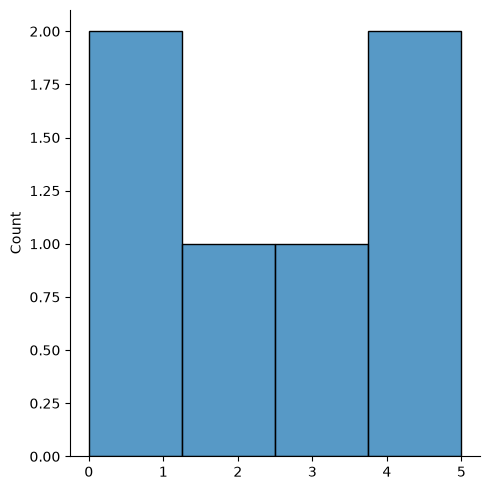

In [281]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.displot([0, 1, 2, 3, 4, 5])

plt.show() 

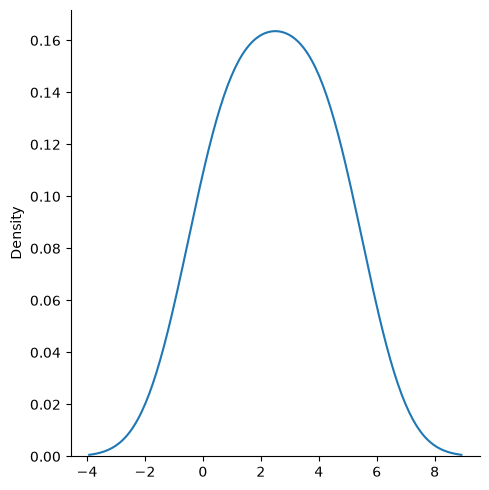

In [282]:
sns.displot([0, 1, 2, 3, 4, 5], kind="kde")

plt.show() 

In [283]:
def myadd(x, y):
  return x+y

myadd = np.frompyfunc(myadd, 2, 1)

print(myadd([1, 2, 3, 4], [5, 6, 7, 8])) 

[6 8 10 12]


In [284]:
arr1 = np.array([10, 20, 30, 40, 50, 60])
arr2 = np.array([20, 21, 22, 23, 24, 25])

newarr = np.multiply(arr1, arr2)

print(newarr) 

[ 200  420  660  920 1200 1500]


In [285]:

arr1 = np.array([10, 20, 30, 40, 50, 60])
arr2 = np.array([3, 5, 10, 8, 2, 33])

newarr = np.divide(arr1, arr2)

print(newarr) 

[ 3.33333333  4.          3.          5.         25.          1.81818182]


In [286]:
arr1 = np.array([10, 20, 30, 40, 50, 60])
arr2 = np.array([3, 5, 6, 8, 2, 33])

newarr = np.power(arr1, arr2)

print(newarr)

[         1000       3200000     729000000 6553600000000          2500
             0]


In [287]:
arr1 = np.array([10, 20, 30, 40, 50, 60])
arr2 = np.array([3, 7, 9, 8, 2, 33])

newarr = np.divmod(arr1, arr2)

print(newarr) 

(array([ 3,  2,  3,  5, 25,  1]), array([ 1,  6,  3,  0,  0, 27]))


In [288]:
arr = np.trunc([-3.5666, 3.6667])

print(arr) 

arr = np.fix([-3.1666, 3.6667])

print(arr)

[-3.  3.]
[-3.  3.]


/tmp/ipykernel_432444/1286354913.py:5: DeprecationWarning: numpy.fix is deprecated. Use numpy.trunc instead, which is faster and follows the Array API standard.
  arr = np.fix([-3.1666, 3.6667])


In [289]:

arr = np.around(3.1666, 3)

print(arr) 

3.167


In [290]:
arr = np.floor([-3.1666, 3.6667])

print(arr) 

[-4.  3.]


In [291]:
arr = np.arange(1, 10)

print(np.log2(arr)) 

[0.         1.         1.5849625  2.         2.32192809 2.5849625
 2.80735492 3.         3.169925  ]


In [292]:
arr = np.array([10, 15, 25, 5])

newarr = np.diff(arr, n=2)

print(newarr) 

[  5 -30]


In [293]:

arr1 = np.array([1, 2, 3, 4])
arr2 = np.array([3, 4, 5, 6])

newarr = np.union1d(arr1, arr2)

print(newarr) 

[1 2 3 4 5 6]


In [294]:
device = torch.device("cuda")

In [295]:
import torch

torch.manual_seed(0)

# ---------------------------------------------------
# Generate training data
# ---------------------------------------------------

# 64 samples, each with 10 features
x = torch.rand(64, 10)

# Create labels manually
y_correct = torch.stack([
    x[:, :5].sum(dim=1),      # first five numbers
    x[:, 5:].sum(dim=1),      # last five numbers
    x.max(dim=1).values,      # maximum
    x.min(dim=1).values       # minimum
], dim=1)

print("Input shape :", x.shape)
print("Target shape:", y_correct.shape)

print("\nFirst sample")
print("x =", x[0])
print("y =", y_correct[0])

x = x.to(device)
y_correct = y_correct.to(device)
# ---------------------------------------------------
# Model
# ---------------------------------------------------

model = torch.nn.Sequential(
    torch.nn.Linear(10,150),
    torch.nn.ReLU(),
    torch.nn.Linear(150,4)
).to(device)

loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005
)

# ---------------------------------------------------
# Training
# ---------------------------------------------------

loss = 10000

while loss > 0.00000001:

    # Forward
    y_pred = model(x)

    # Loss
    loss = loss_fn(y_pred, y_correct)

    # Clear old gradients
    optimizer.zero_grad()

    # Compute new gradients
    loss.backward()

    # Update parameters
    optimizer.step()

    print(f"Loss = {loss.item():.6f}")

    print("\nPrediction:")
    print(y_pred[0].detach())

    print("\nGround Truth:")
    print(y_correct[0])

Input shape : torch.Size([64, 10])
Target shape: torch.Size([64, 4])

First sample
x = tensor([0.4963, 0.7682, 0.0885, 0.1320, 0.3074, 0.6341, 0.4901, 0.8964, 0.4556,
        0.6323])
y = tensor([1.7924, 3.1086, 0.8964, 0.0885])
Loss = 3.665353

Prediction:
tensor([ 0.0144, -0.0591, -0.1053, -0.0824], device='cuda:0')

Ground Truth:
tensor([1.7924, 3.1086, 0.8964, 0.0885], device='cuda:0')
Loss = 3.172814

Prediction:
tensor([0.1749, 0.0839, 0.0242, 0.0150], device='cuda:0')

Ground Truth:
tensor([1.7924, 3.1086, 0.8964, 0.0885], device='cuda:0')
Loss = 2.728823

Prediction:
tensor([0.3360, 0.2264, 0.1541, 0.0881], device='cuda:0')

Ground Truth:
tensor([1.7924, 3.1086, 0.8964, 0.0885], device='cuda:0')
Loss = 2.317395

Prediction:
tensor([0.5005, 0.3748, 0.2811, 0.1157], device='cuda:0')

Ground Truth:
tensor([1.7924, 3.1086, 0.8964, 0.0885], device='cuda:0')
Loss = 1.930870

Prediction:
tensor([0.6678, 0.5308, 0.4104, 0.1039], device='cuda:0')

Ground Truth:
tensor([1.7924, 3.1086, 0

In [296]:
print(x.device)
print(next(model.parameters()).device)

cuda:0
cuda:0


In [ ]:
def one_hot(N=10, pos=0, val=1):
    one_hot_vec = np.zeros(N)
    one_hot_vec[pos] = val
    return one_hot_vec

In [ ]:
arms = 10
s = 10

In [ ]:
def train():
    state = one_hot()